Model Accuracy: 0.9


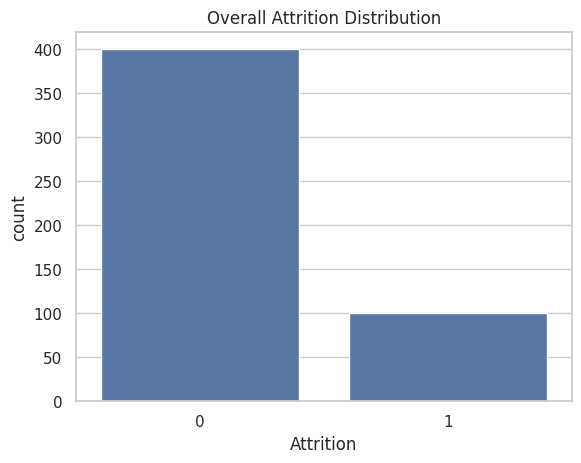

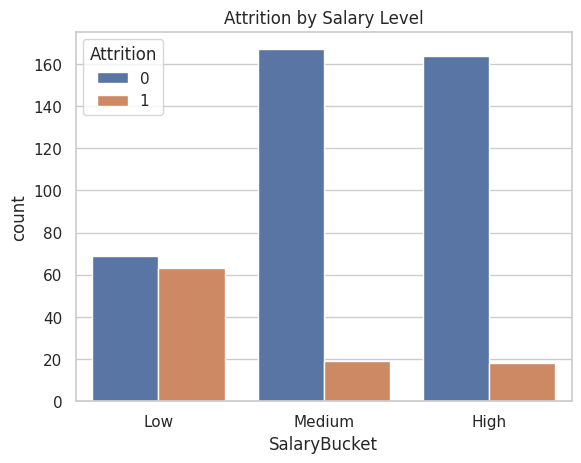

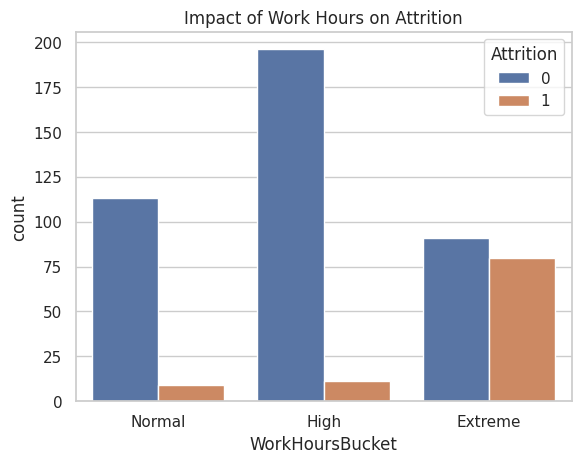

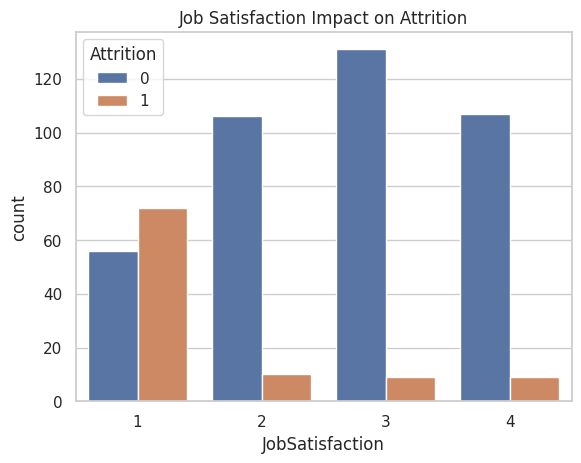

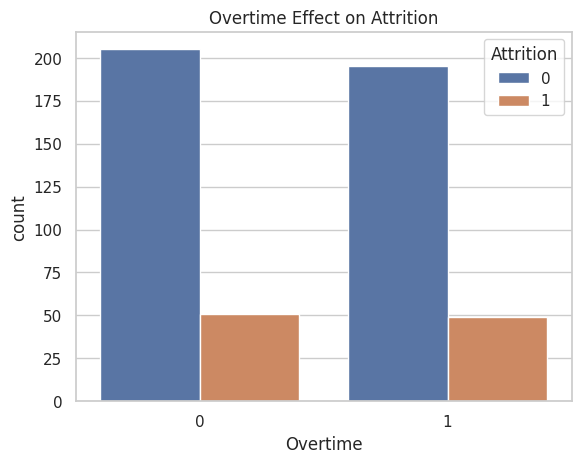

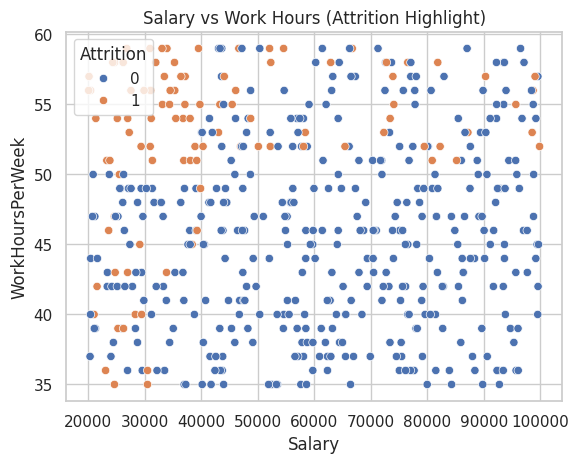

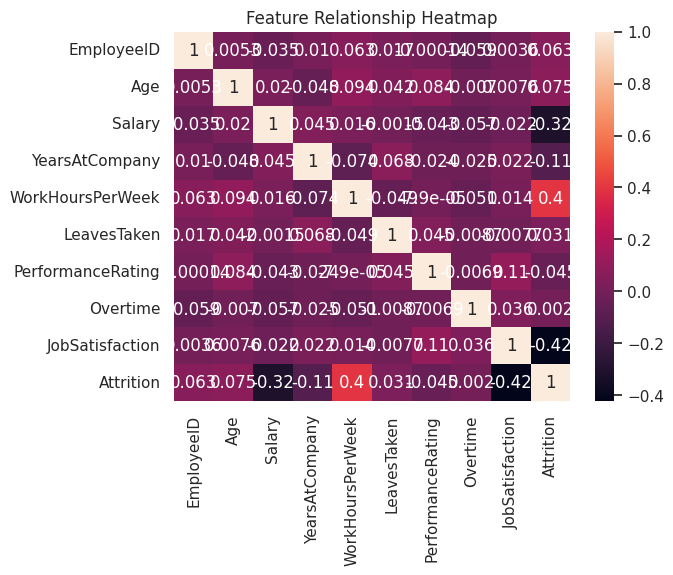

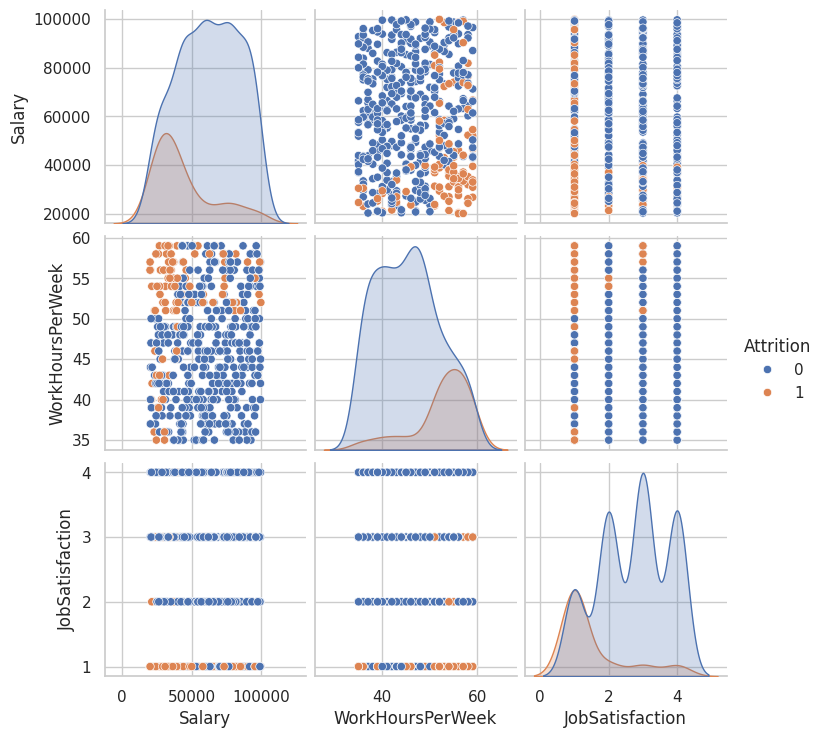

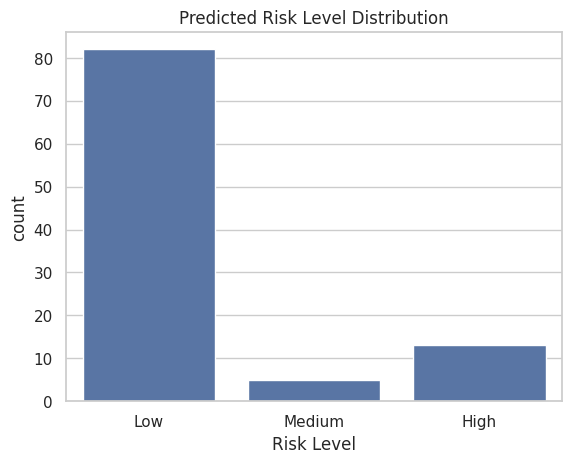


🔍 KEY INSIGHTS:

1. Attrition Rate: 20.0 %

2. High Attrition in Low Salary:
SalaryBucket
Low       0.477273
Medium    0.102151
High      0.098901
Name: Attrition, dtype: float64

3. Work Hours Impact:
WorkHoursBucket
Normal     0.073770
High       0.053140
Extreme    0.467836
Name: Attrition, dtype: float64

4. Job Satisfaction Impact:
JobSatisfaction
1    0.562500
2    0.086207
3    0.064286
4    0.077586
Name: Attrition, dtype: float64

5. Overtime Impact:
Overtime
0    0.199219
1    0.200820
Name: Attrition, dtype: float64


/tmp/ipykernel_5175/1652968337.py:158: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("SalaryBucket")["Attrition"].mean())
/tmp/ipykernel_5175/1652968337.py:161: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("WorkHoursBucket")["Attrition"].mean())


In [ ]:
 # =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# =========================================
# 2. Generate Dataset
# =========================================
np.random.seed(42)

n = 500

df = pd.DataFrame({
    "EmployeeID": range(1, n+1),
    "Age": np.random.randint(22, 50, n),
    "Salary": np.random.randint(20000, 100000, n),
    "YearsAtCompany": np.random.randint(1, 10, n),
    "WorkHoursPerWeek": np.random.randint(35, 60, n),
    "LeavesTaken": np.random.randint(0, 20, n),
    "PerformanceRating": np.random.randint(1, 5, n),
    "Overtime": np.random.choice([0,1], n),
    "JobSatisfaction": np.random.randint(1, 5, n)
})

# Attrition logic
df["Attrition"] = (
    (df["Salary"] < 40000).astype(int) +
    (df["WorkHoursPerWeek"] > 50).astype(int) +
    (df["JobSatisfaction"] < 2).astype(int)
)
df["Attrition"] = df["Attrition"].apply(lambda x: 1 if x >= 2 else 0)

# =========================================
# 3. ML Model
# =========================================
X = df[['Age','Salary','YearsAtCompany','WorkHoursPerWeek',
        'LeavesTaken','PerformanceRating','Overtime','JobSatisfaction']]
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Model Accuracy:", round(accuracy_score(y_test, y_pred), 2))

# Risk Level
def risk_level(p):
    if p > 0.7:
        return "High"
    elif p > 0.4:
        return "Medium"
    else:
        return "Low"

result = X_test.copy()
result["Risk %"] = y_prob
result["Risk Level"] = [risk_level(p) for p in y_prob]

# =========================================
# 4. DERIVED DATA (IMPORTANT)
# =========================================

# Salary Buckets
df["SalaryBucket"] = pd.cut(df["Salary"],
                           bins=[0,40000,70000,100000],
                           labels=["Low","Medium","High"])

# Work Hours Bucket
df["WorkHoursBucket"] = pd.cut(df["WorkHoursPerWeek"],
                              bins=[0,40,50,70],
                              labels=["Normal","High","Extreme"])

# =========================================
# 5. VISUALIZATIONS (INSIGHT FOCUSED)
# =========================================

# 1. Attrition Distribution
plt.figure()
sns.countplot(x="Attrition", data=df)
plt.title("Overall Attrition Distribution")
plt.show()

# 2. Salary Bucket vs Attrition
plt.figure()
sns.countplot(x="SalaryBucket", hue="Attrition", data=df)
plt.title("Attrition by Salary Level")
plt.show()

# 3. Work Hours vs Attrition
plt.figure()
sns.countplot(x="WorkHoursBucket", hue="Attrition", data=df)
plt.title("Impact of Work Hours on Attrition")
plt.show()

# 4. Job Satisfaction vs Attrition
plt.figure()
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)
plt.title("Job Satisfaction Impact on Attrition")
plt.show()

# 5. Overtime vs Attrition
plt.figure()
sns.countplot(x="Overtime", hue="Attrition", data=df)
plt.title("Overtime Effect on Attrition")
plt.show()

# 6. Salary vs WorkHours (Relationship)
plt.figure()
sns.scatterplot(x="Salary", y="WorkHoursPerWeek", hue="Attrition", data=df)
plt.title("Salary vs Work Hours (Attrition Highlight)")
plt.show()

# 7. Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Relationship Heatmap")
plt.show()

# 8. Pairplot (Advanced Relationship View)
sns.pairplot(df[['Salary','WorkHoursPerWeek','JobSatisfaction','Attrition']], hue="Attrition")
plt.show()

# 9. Risk Distribution
plt.figure()
sns.countplot(x=result["Risk Level"])
plt.title("Predicted Risk Level Distribution")
plt.show()

# =========================================
# 6. BUSINESS INSIGHTS PRINT
# =========================================
print("\n🔍 KEY INSIGHTS:")

print("\n1. Attrition Rate:",
      round(df["Attrition"].mean()*100,2), "%")

print("\n2. High Attrition in Low Salary:")
print(df.groupby("SalaryBucket")["Attrition"].mean())

print("\n3. Work Hours Impact:")
print(df.groupby("WorkHoursBucket")["Attrition"].mean())

print("\n4. Job Satisfaction Impact:")
print(df.groupby("JobSatisfaction")["Attrition"].mean())

print("\n5. Overtime Impact:")
print(df.groupby("Overtime")["Attrition"].mean())